##### Simplex de Nelder-Mead

O código implementa o algoritmo Nelder-Mead, um método de otimização sem derivadas, para encontrar o mínimo ou máximo de uma função. O algoritmo opera sobre um simplex (um triângulo em 2D) e ajusta seus vértices iterativamente por meio de operações como reflexão, expansão, contração e redução. O código também gera visualizações gráficas, exibindo cada simplex em uma figura separada por iteração e um gráfico final com todos os simplexes, mostrando a convergência.

- Importação de Bibliotecas: Carrega as bibliotecas necessárias para cálculos numéricos, visualização e comparação com uma implementação padrão.

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize #utilizada apenas como meio de comparação

- Função Objetivo: Define a função a ser otimizada.


In [190]:
def funcao_objetivo(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2


Funções Auxiliares do Nelder-Mead: Implementa operações para criar e manipular o simplex.

- Gera o simplex inicial com n+1 pontos ao redor de x0

In [191]:
def simplex_inicial(x0, passo=0.1):
    n = len(x0)  # Dimensão do problema (2 para 2D)
    simplex = np.zeros((n + 1, n))  # Inicializa matriz para n+1 vértices
    simplex[0] = x0  # Primeiro vértice é o ponto inicial
    for i in range(n):
        delta = np.zeros(n)  # Vetor de deslocamento com zeros
        delta[i] = passo  # Desloca apenas a i-ésima coordenada
        simplex[i + 1] = x0 + delta  # Adiciona vértice deslocado
    return simplex

- Ordena os vértices do melhor (menor valor) ao pior (maior valor) da função

In [192]:
def ordenar_simplex(simplex):
    valores_f = np.array([funcao_objetivo(x) for x in simplex])  # Avalia função em cada vértice
    indices = np.argsort(valores_f)  # Obtém índices para ordenar do menor ao maior
    return simplex[indices], valores_f[indices]  # Retorna simplex e valores ordenados

- Realiza a operação de reflexão

In [193]:
def refletir(simplex, valores_f, alpha=1.0):
    x_melhor = simplex[0]  # Melhor vértice (menor valor)
    x_pior = simplex[-1]  # Pior vértice (maior valor)
    x_centroide = np.mean(simplex[:-1], axis=0)  # Calcula o centroide, exceto o pior
    x_ref = x_centroide + alpha * (x_centroide - x_pior)  # Calcula ponto refletido
    f_ref = funcao_objetivo(x_ref)  # Avalia função no ponto refletido
    return x_ref, f_ref

- Realiza a operação de expansão

In [194]:
def expandir(simplex, x_ref, f_ref, gamma=2.0):
    x_centroide = np.mean(simplex[:-1], axis=0)  # Calcula o centroide, exceto o pior
    x_exp = x_centroide + gamma * (x_ref - x_centroide)  # Calcula ponto expandido
    f_exp = funcao_objetivo(x_exp)  # Avalia função no ponto expandido
    return x_exp, f_exp

- Realiza a contração externa

In [195]:
def contrair_externo(simplex, x_ref, f_ref, rho=0.5):
    x_centroide = np.mean(simplex[:-1], axis=0)  # Calcula o centroide, exceto o pior
    x_contracao = x_centroide + rho * (x_ref - x_centroide)  # Calcula ponto contraído
    f_contracao = funcao_objetivo(x_contracao)  # Avalia função no ponto contraído
    return x_contracao, f_contracao

- Realiza a contração interna

In [196]:
def contrair_interno(simplex, x_pior, f_pior, beta=0.5):
    x_centroide = np.mean(simplex[:-1], axis=0)  # Calcula o centroide, exceto o pior
    x_contracao = x_centroide + beta * (x_pior - x_centroide)  # Calcula ponto contraído
    f_contracao = funcao_objetivo(x_contracao)  # Avalia função no ponto contraído
    return x_contracao, f_contracao

- Realiza a redução do simplex

In [197]:
def reduzir(simplex, x_melhor, sigma=0.5):
    n = simplex.shape[0]  # Número de vértices
    novo_simplex = np.zeros_like(simplex)  # Inicializa novo simplex com mesma forma
    novo_simplex[0] = x_melhor  # Mantém o melhor vértice
    for i in range(1, n):
        novo_simplex[i] = x_melhor + sigma * (simplex[i] - x_melhor)  # Reduz outros vértices
    return novo_simplex

Algoritmo Nelder-Mead: Executa o algoritmo principal, armazenando o histórico de simplexes.

In [198]:
def nelder_mead(x0, tolerancia=1e-6, max_iter=100, alpha=1.0, gamma=2.0, rho=0.5, beta=0.5, sigma=0.5):
    simplex = simplex_inicial(x0)  # Cria simplex inicial
    simplex, valores_f = ordenar_simplex(simplex)  # Ordena vértices
    historico = [simplex.copy()]  # Armazena simplex inicial no histórico
    
    for iteracao in range(max_iter):  # Loop até o número máximo de iterações
        x_ref, f_ref = refletir(simplex, valores_f)  # Tenta reflexão
        if valores_f[0] <= f_ref < valores_f[-2]:  # Se reflexão é aceitável
            simplex[-1] = x_ref  # Substitui pior vértice pelo refletido
        elif f_ref < valores_f[0]:  # Se reflexão é melhor que o melhor
            x_exp, f_exp = expandir(simplex, x_ref, f_ref)  # Tenta expansão
            simplex[-1] = x_exp if f_exp < f_ref else x_ref  # Escolhe expansão ou reflexão
        elif f_ref >= valores_f[-2]:  # Se reflexão não é boa
            if f_ref < valores_f[-1]:  # Se reflexão é melhor que o pior
                x_contracao, f_contracao = contrair_externo(simplex, x_ref, f_ref)  # Contração externa
            else:  # Se reflexão é pior que o pior
                x_contracao, f_contracao = contrair_interno(simplex, simplex[-1], valores_f[-1])  # Contração interna
            if f_contracao < min(f_ref, valores_f[-1]):  # Se contração é melhor
                simplex[-1] = x_contracao  # Substitui pior vértice
            else:  # Se contração falha
                simplex = reduzir(simplex, simplex[0])  # Reduz simplex
        
        simplex, valores_f = ordenar_simplex(simplex)  # Reordena vértices
        historico.append(simplex.copy())  # Armazena simplex atual
        
        if np.max(np.abs(valores_f[:-1] - valores_f[1:])) < tolerancia:  # Verifica convergência
            break
    
    return simplex[0], historico  # Retorna melhor ponto e histórico

Função de Visualização: Gera gráficos separados para cada iteração e um gráfico final com todos os simplexes.

In [199]:
def plt_evolucao(historico, x_range=(-2, 2), y_range=(-1, 3)):
    # Configurar a grade para o gráfico de contorno
    x = np.linspace(x_range[0], x_range[1], 100)
    y = np.linspace(y_range[0], y_range[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = funcao_objetivo([X, Y])
    
    # Plotar cada iteração em uma figura separada
    for i, simplex in enumerate(historico):
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.contour(X, Y, Z, levels=20)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(f'Iteração {i + 1}')
        ax.axis('equal')
        
        # Desenhar o triângulo atual
        triangulo = plt.Polygon(simplex, edgecolor='r', fill=False, alpha=0.5)
        ax.add_patch(triangulo)
        
        # Adicionar pontos para o simplex inicial e final
        if i == 0:
            ax.scatter(simplex[:, 0], simplex[:, 1], c='b', label='Inicial')
        elif i == len(historico) - 1:
            ax.scatter(simplex[0, 0], simplex[0, 1], c='g', label='Final')
        
        if i in [0, len(historico) - 1]:
            ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Plotar todos os simplexes em uma figura final
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contour(X, Y, Z, levels=20)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Todos os Simplexes')
    ax.axis('equal')
    
    # Desenhar todos os triângulos com transparência
    for i, simplex in enumerate(historico):
        triangulo = plt.Polygon(simplex, edgecolor='r', fill=False, alpha=0.3)
        ax.add_patch(triangulo)
        if i == 0:
            ax.scatter(simplex[:, 0], simplex[:, 1], c='b', label='Inicial')
        elif i == len(historico) - 1:
            ax.scatter(simplex[0, 0], simplex[0, 1], c='g', label='Final')
    
    ax.legend()
    plt.tight_layout()
    plt.show()

Execução e Resultados: Roda o algoritmo, compara com a implementação do SciPy e exibe os gráficos.

Resultado manual: [1.0000686 1.0002194]
Resultado SciPy: [1.00000439 1.00001064]


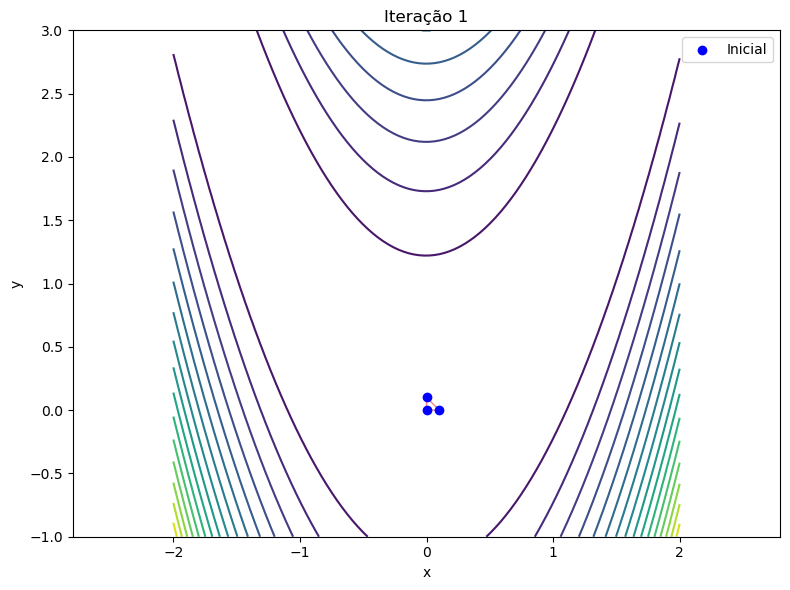

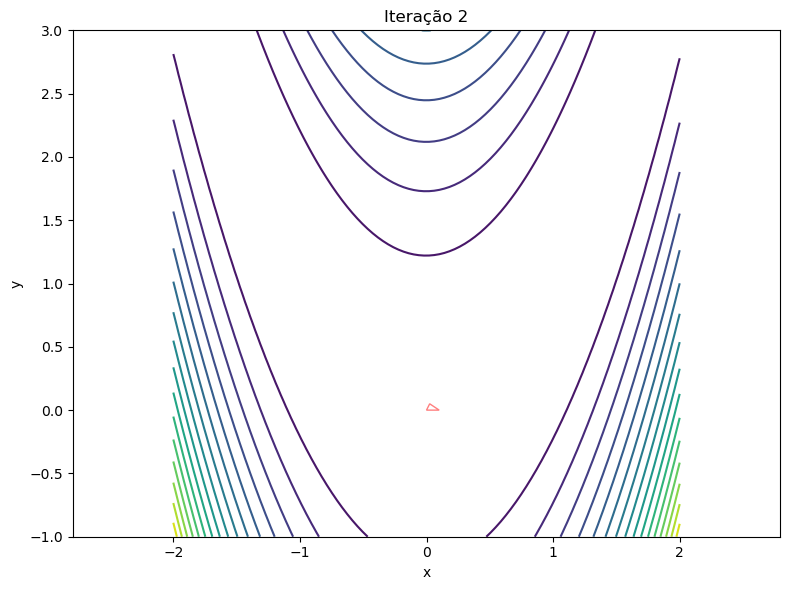

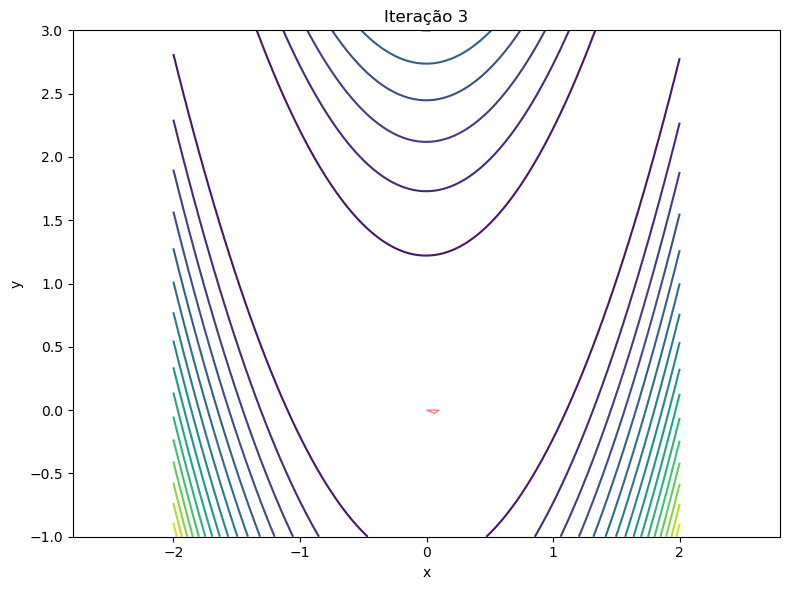

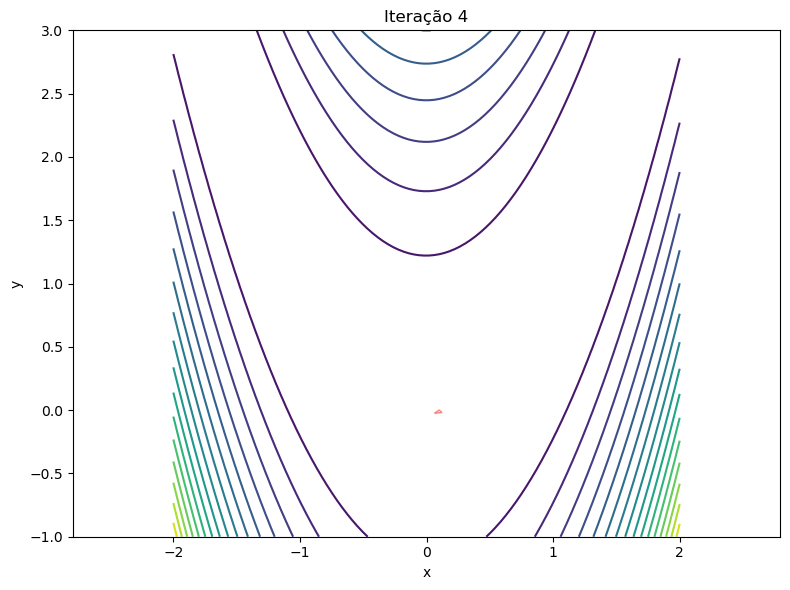

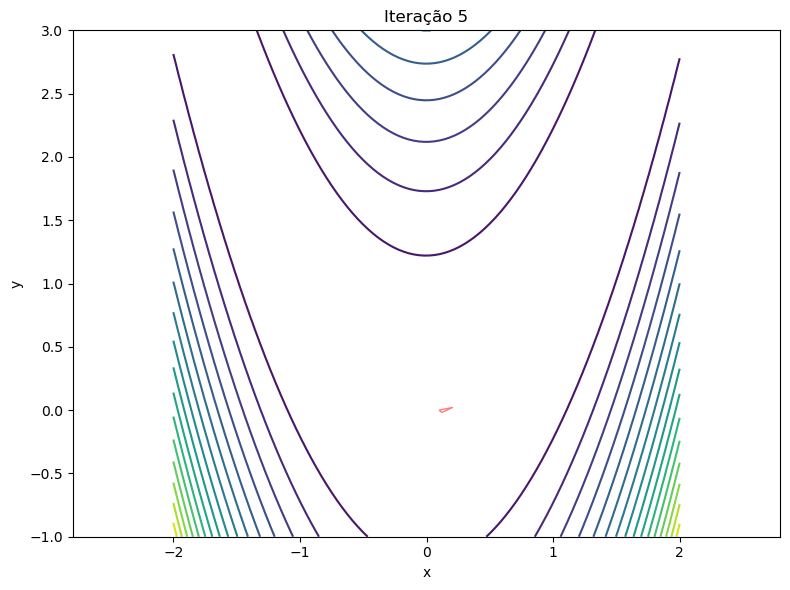

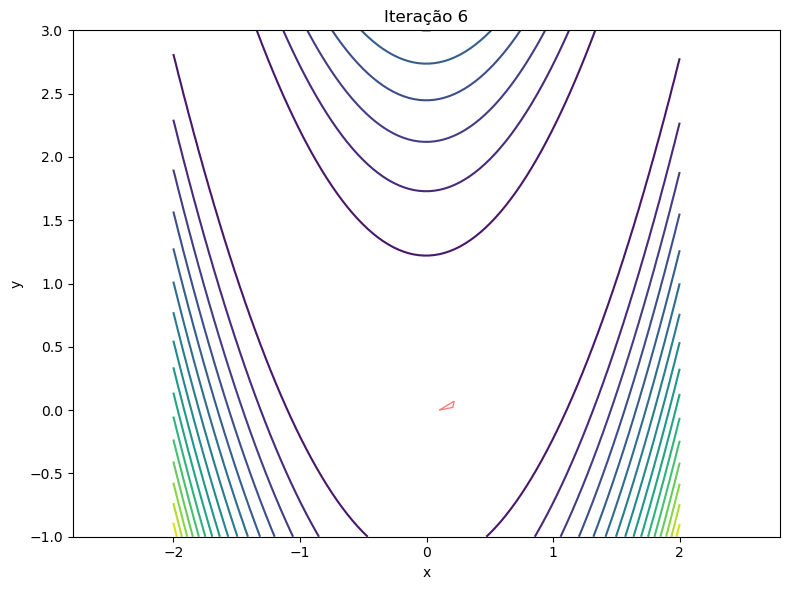

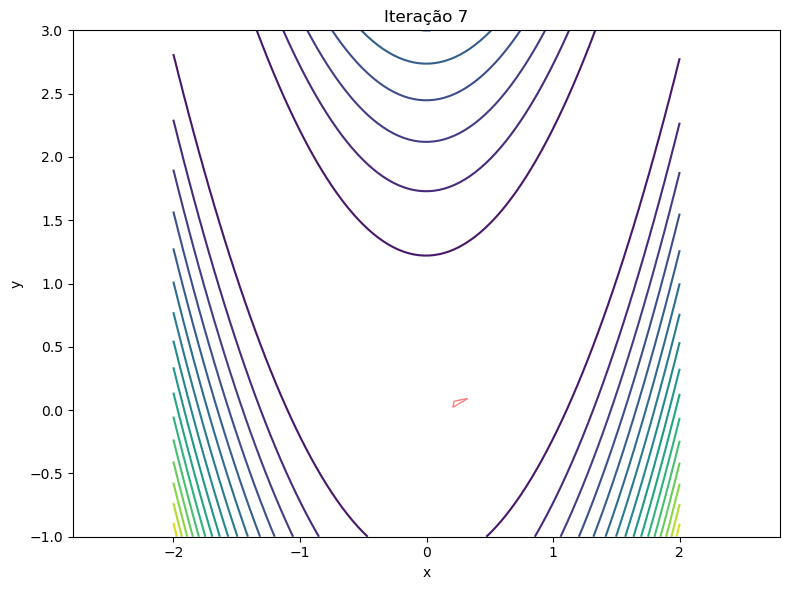

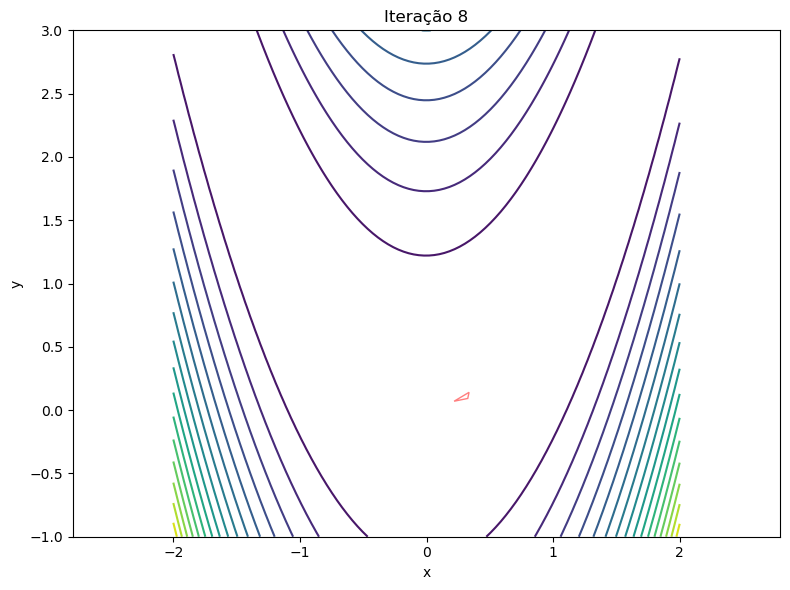

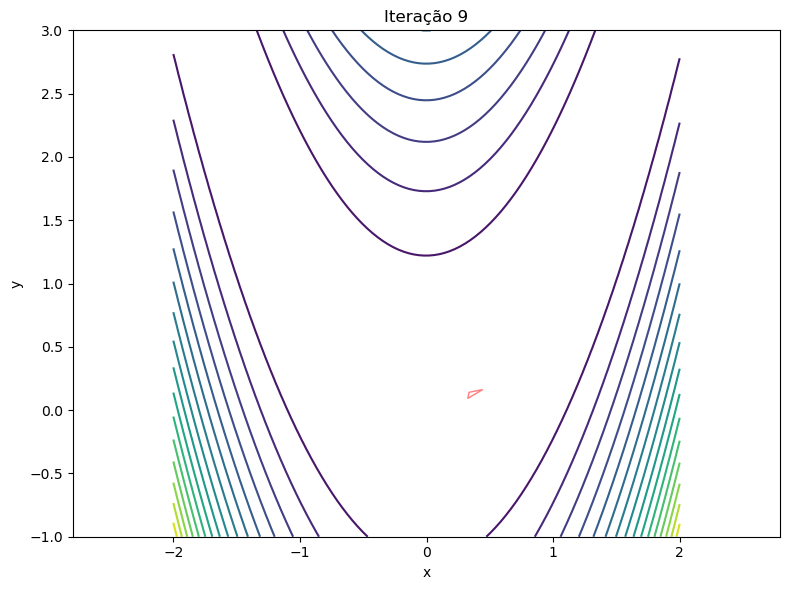

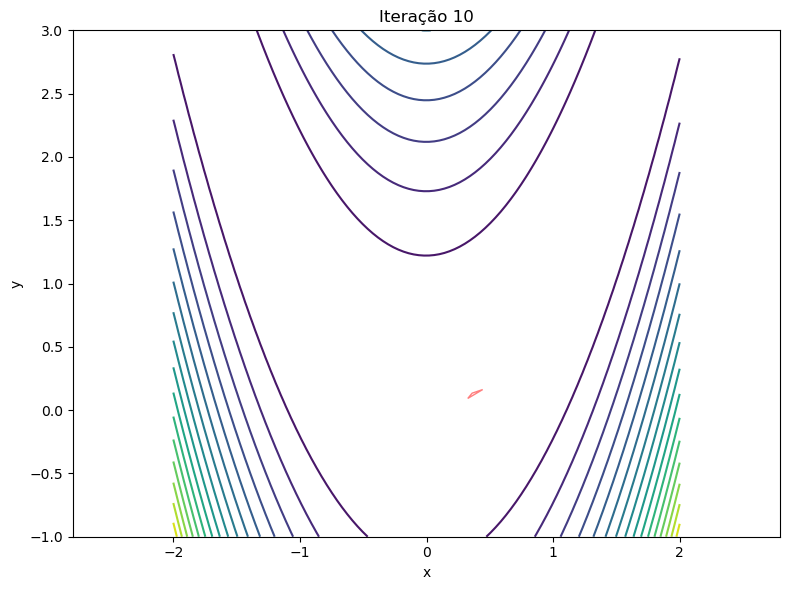

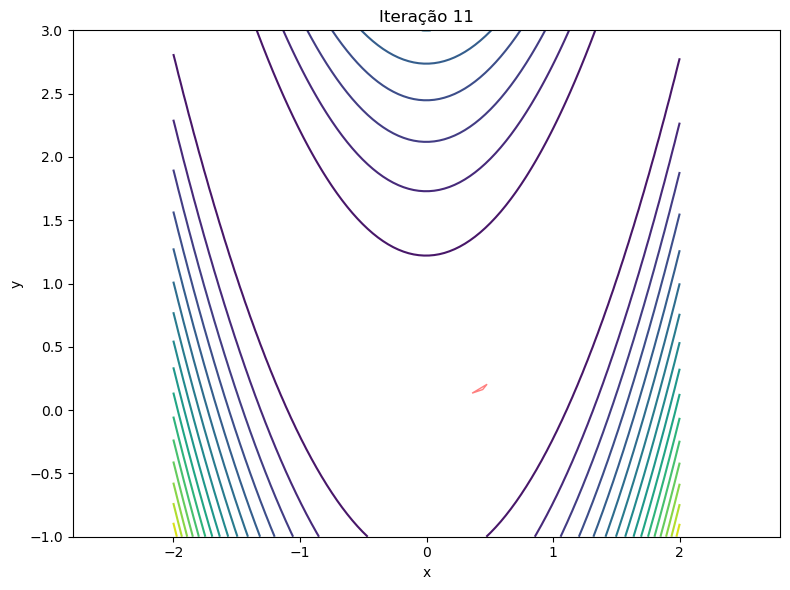

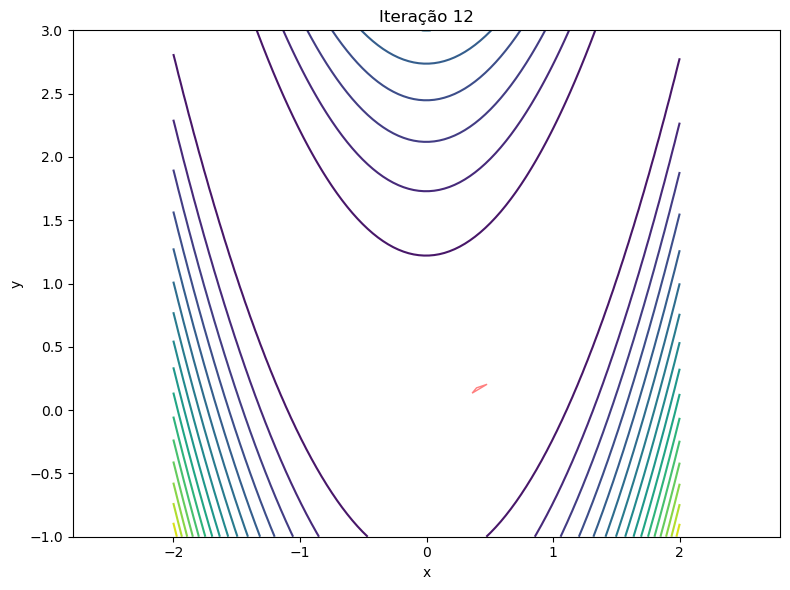

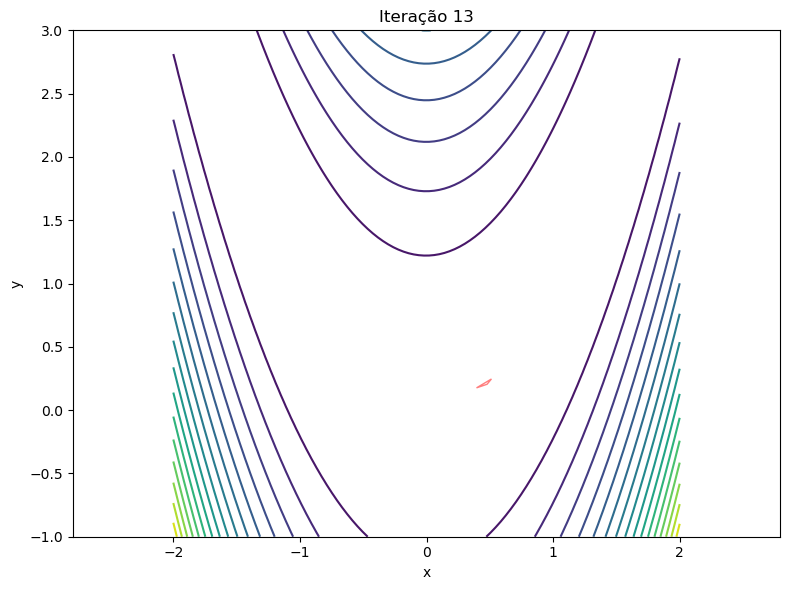

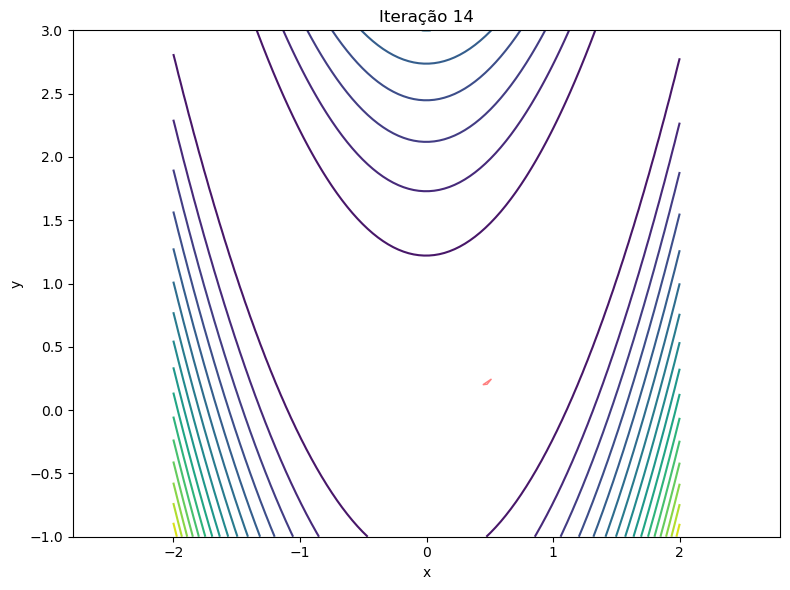

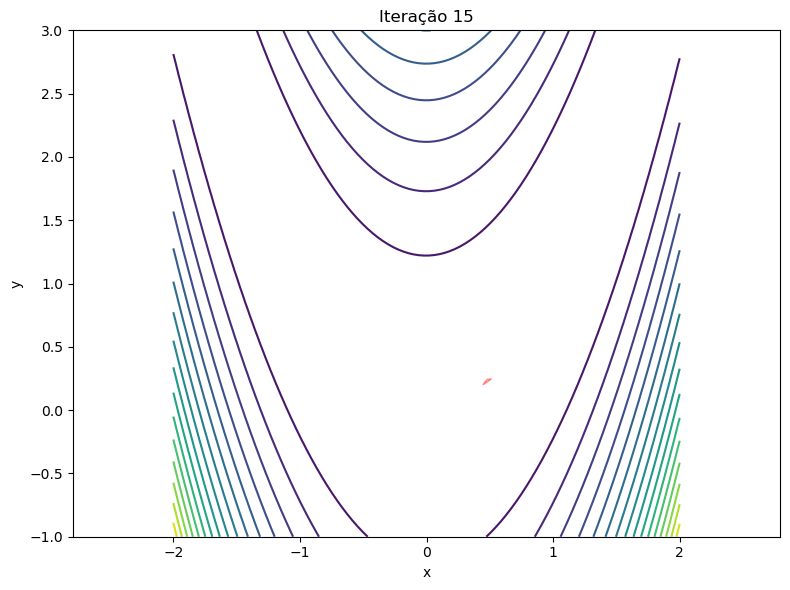

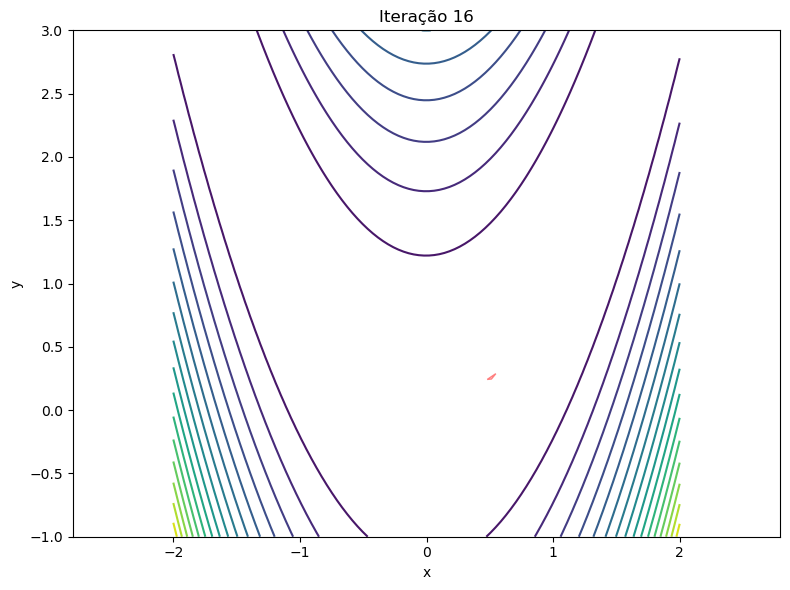

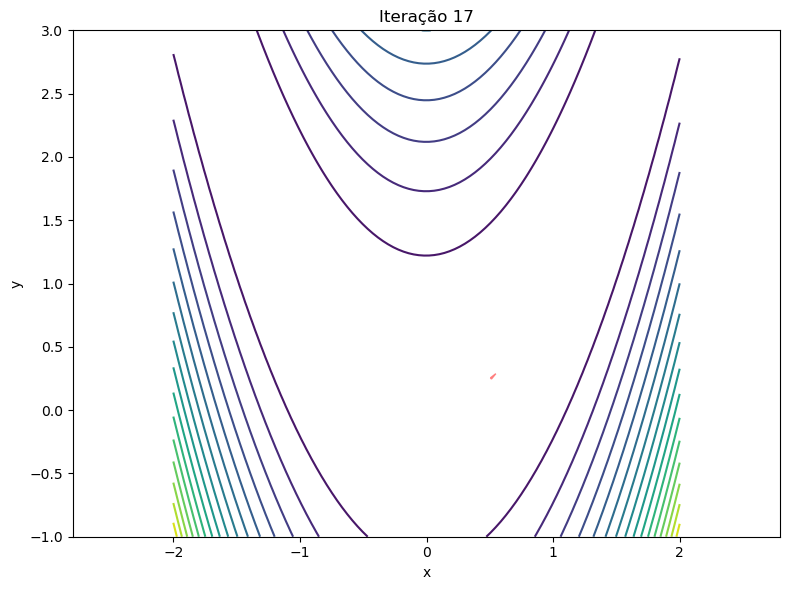

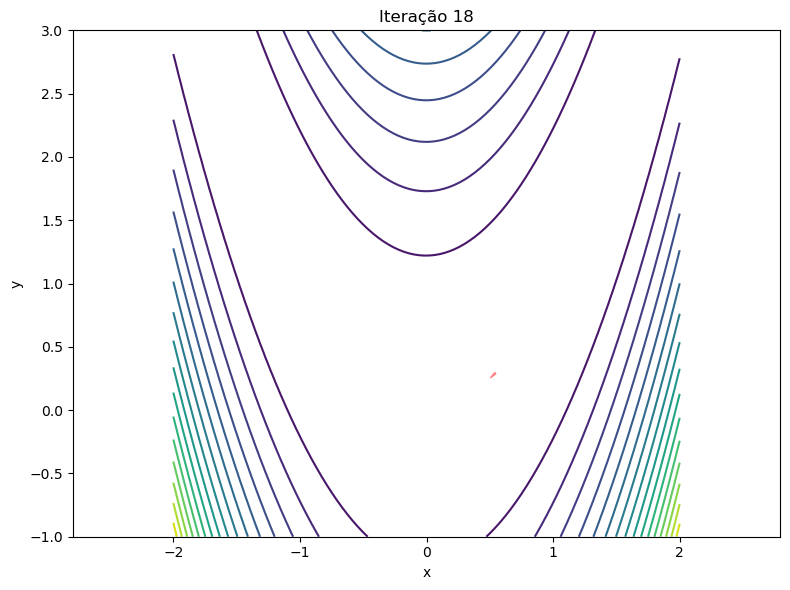

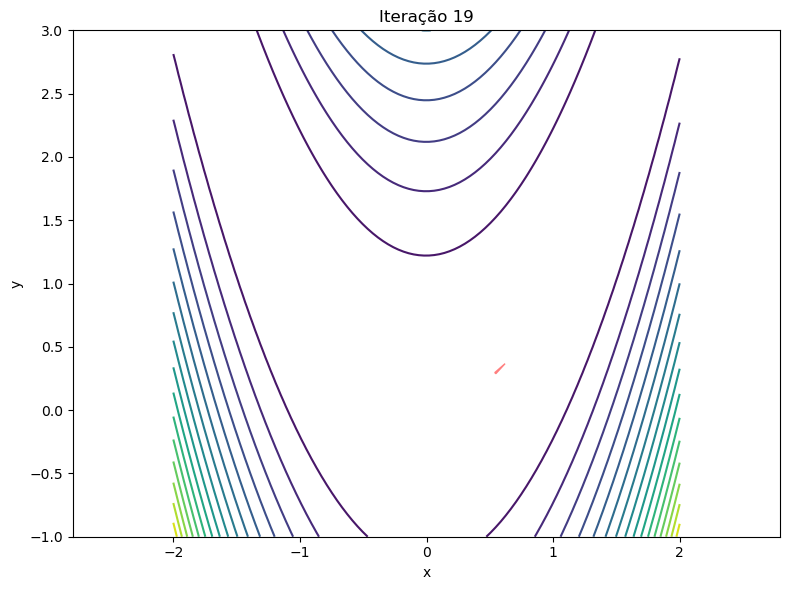

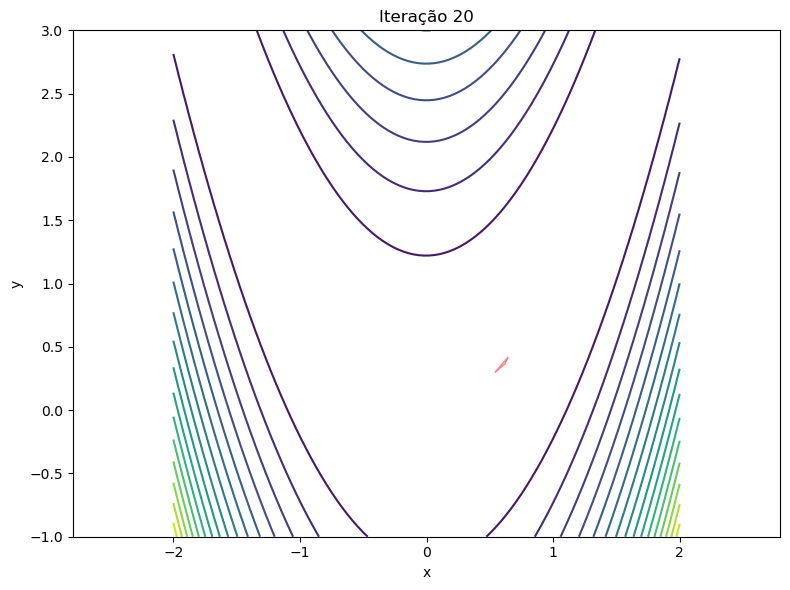

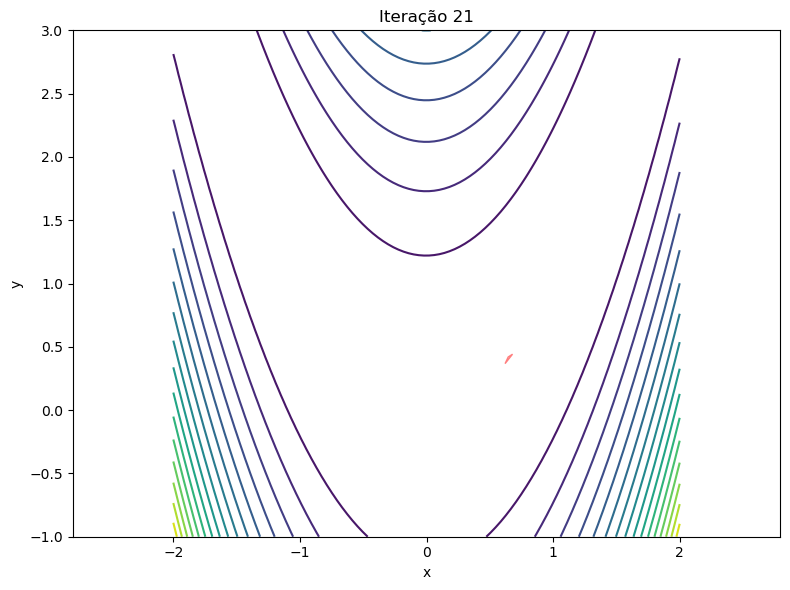

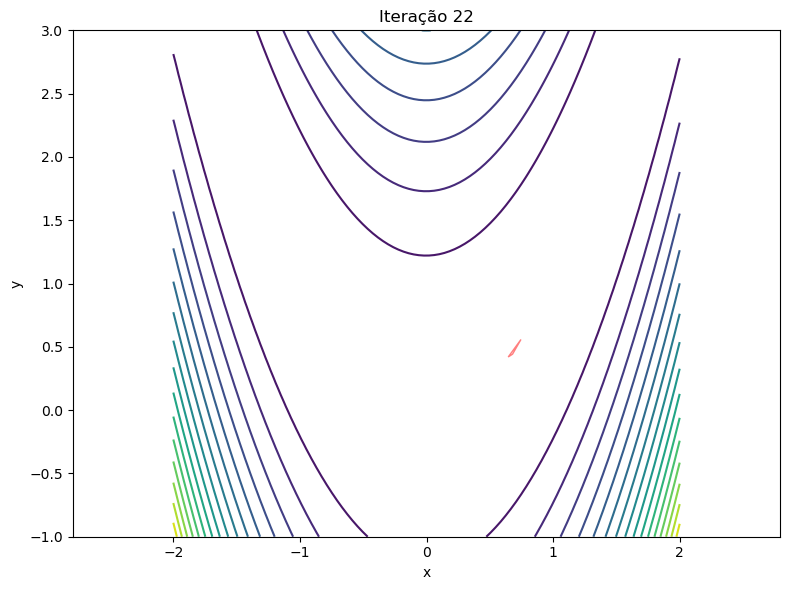

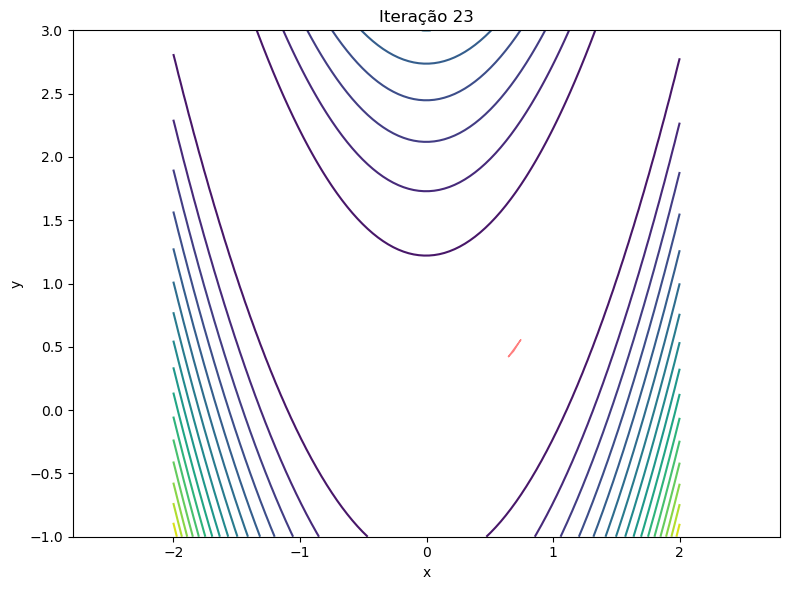

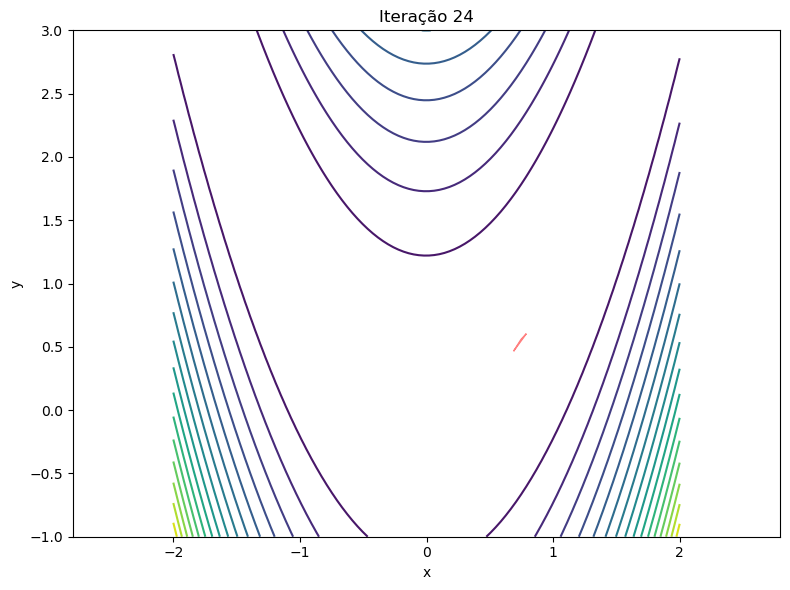

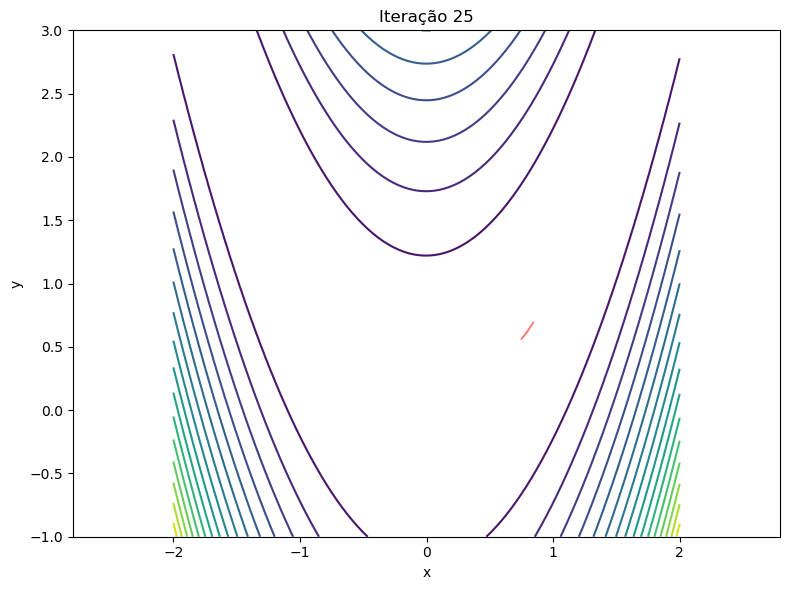

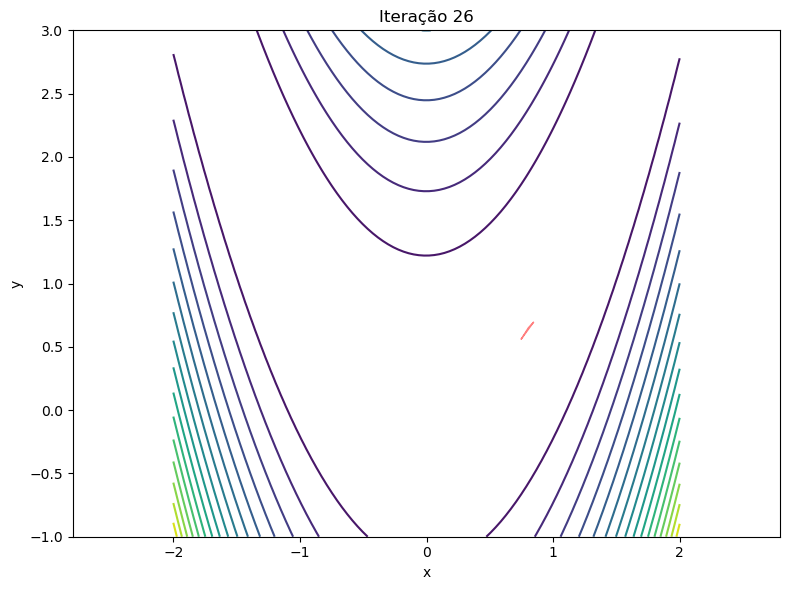

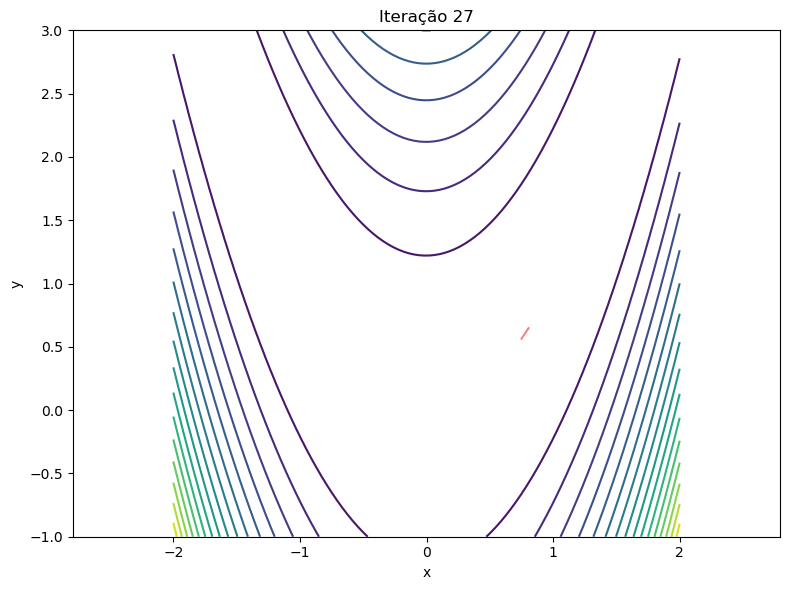

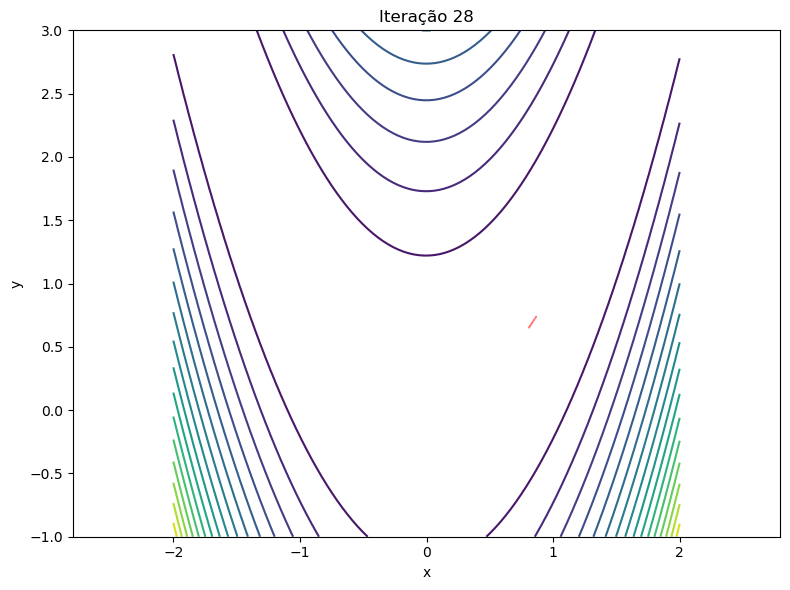

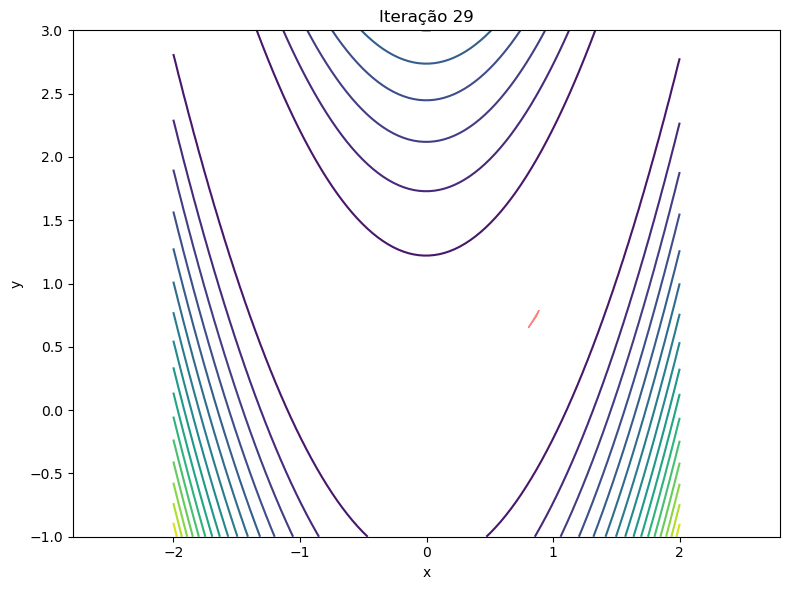

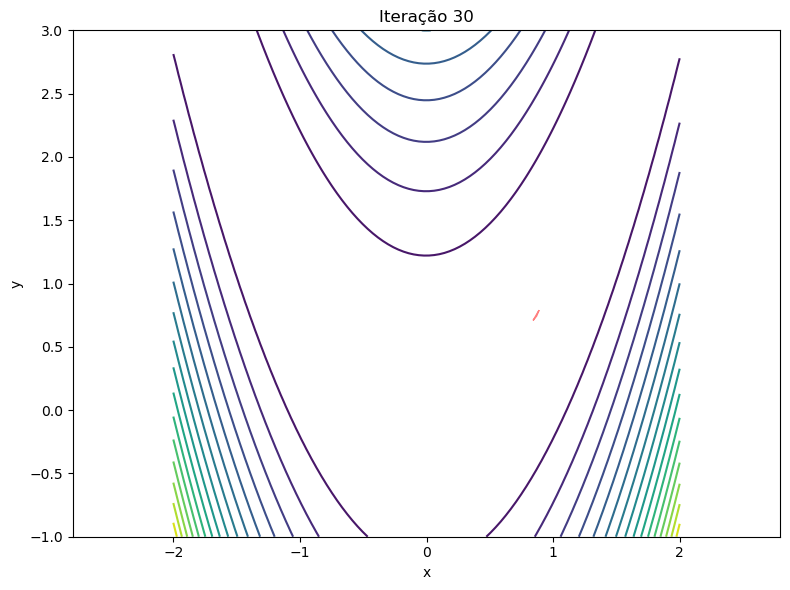

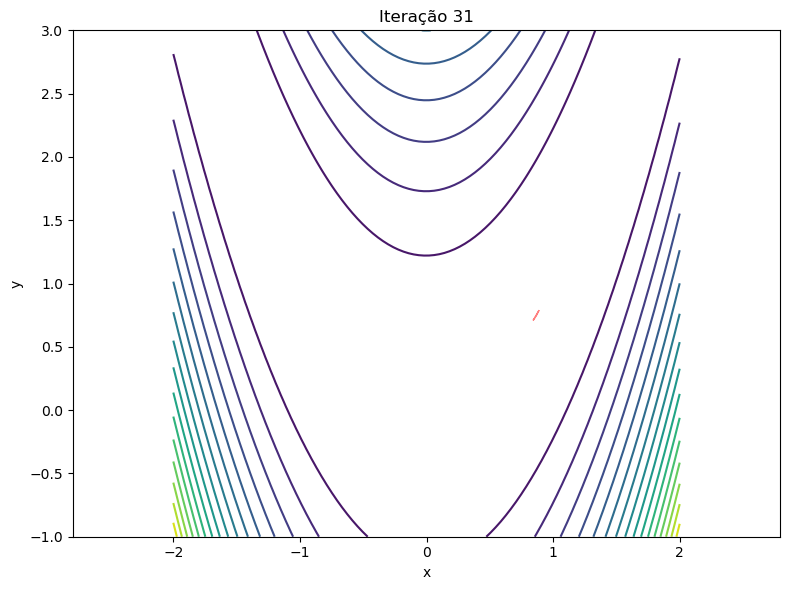

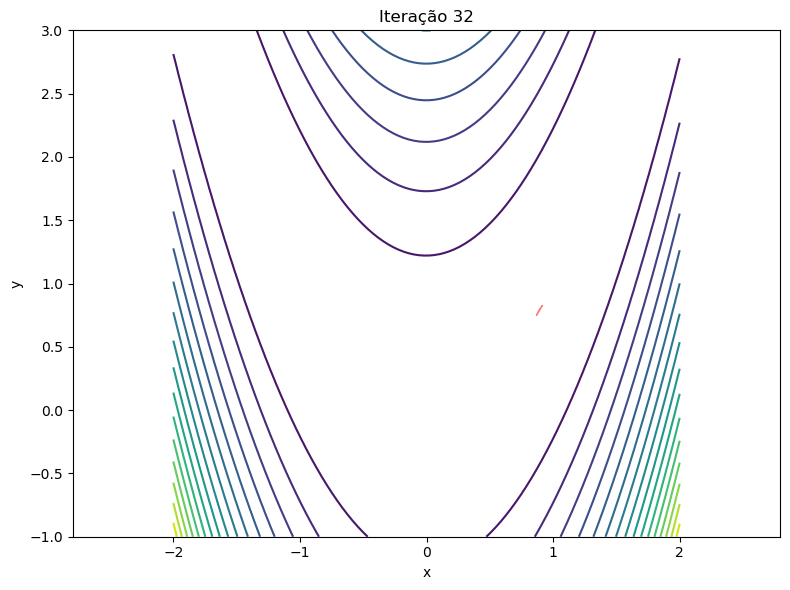

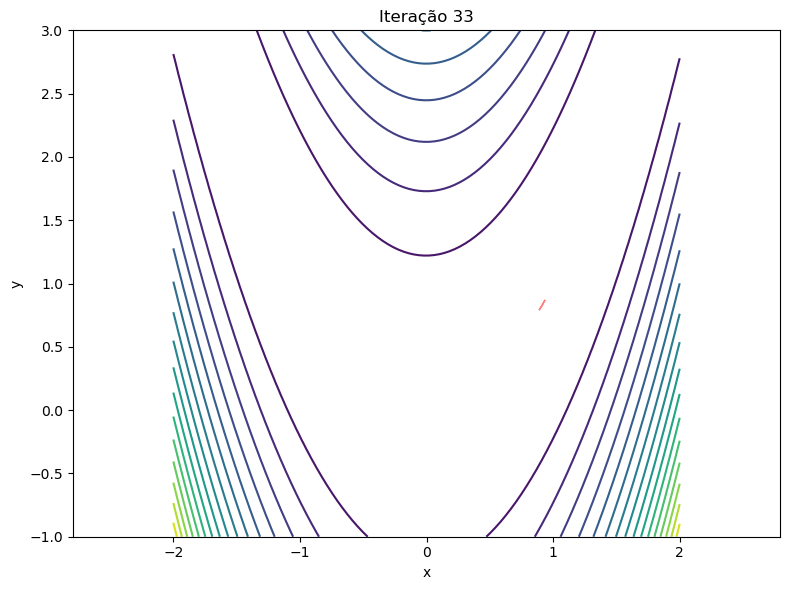

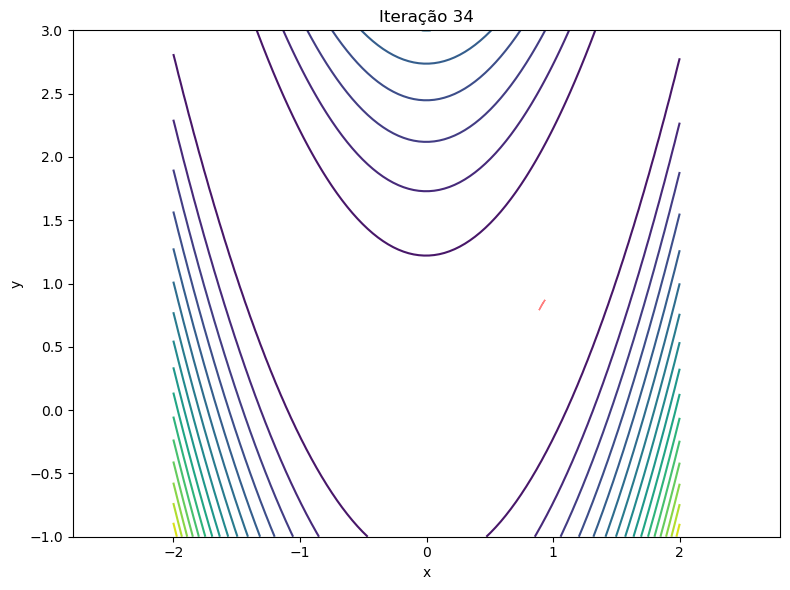

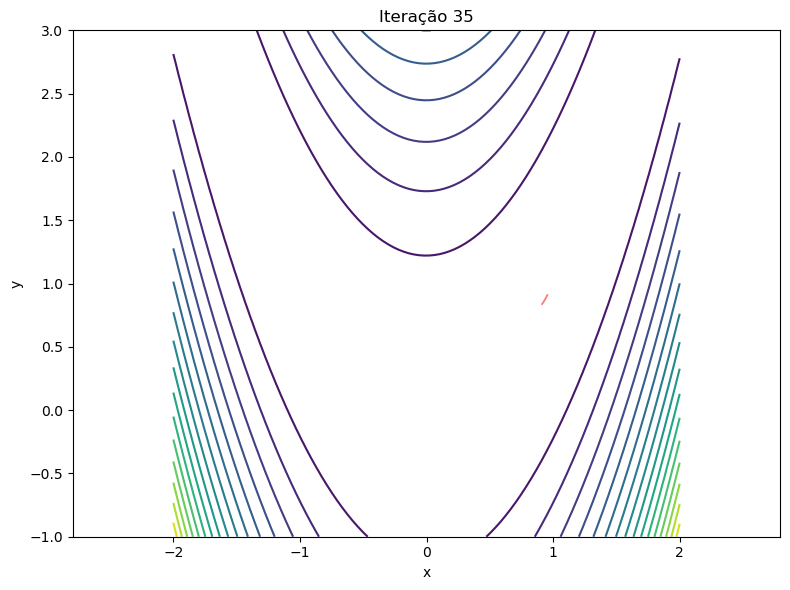

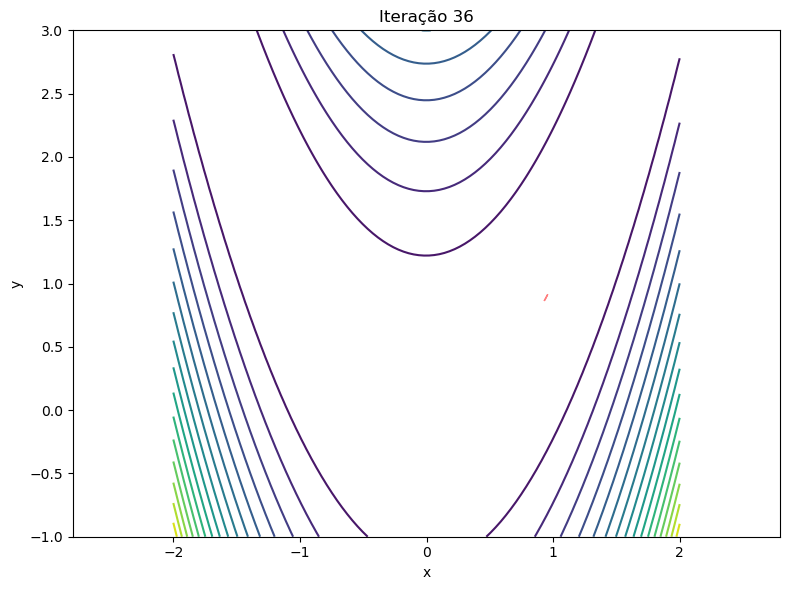

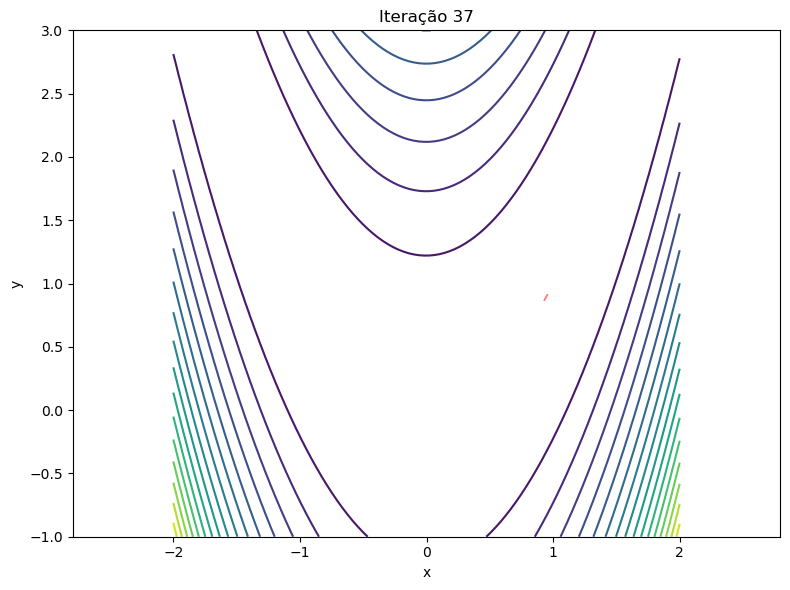

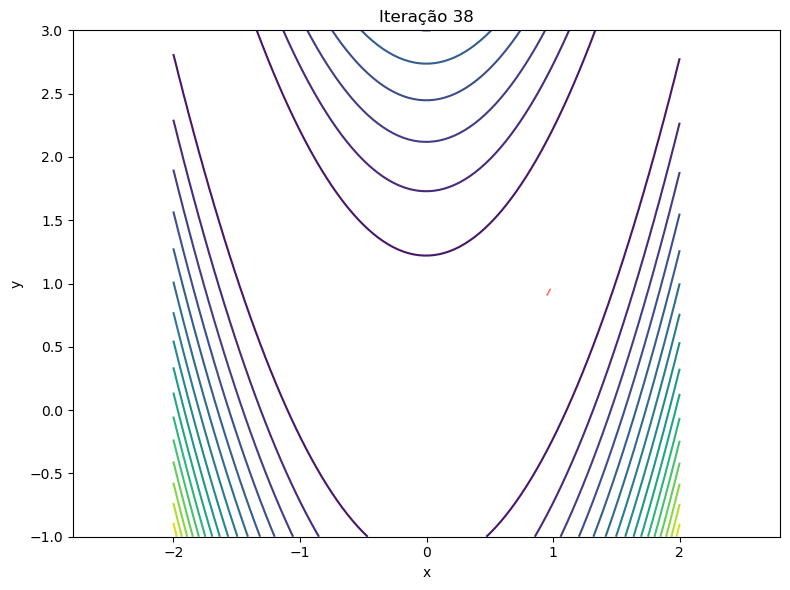

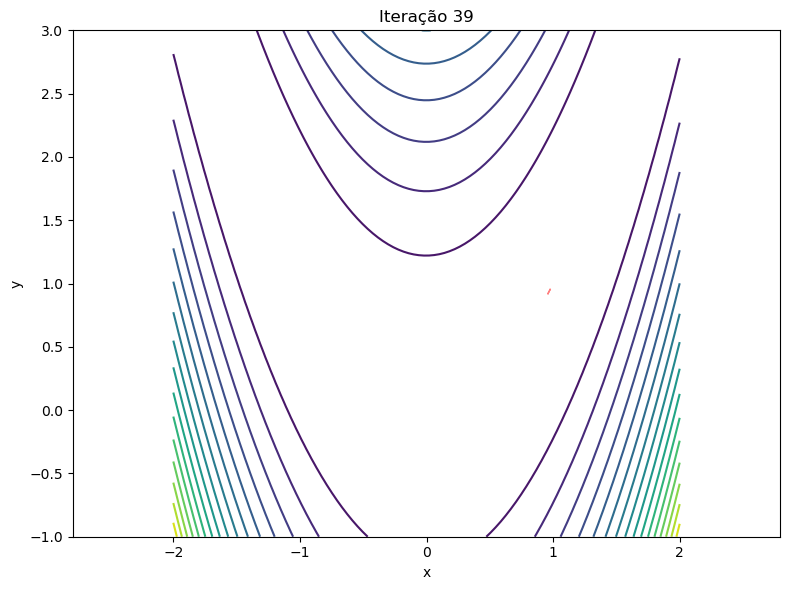

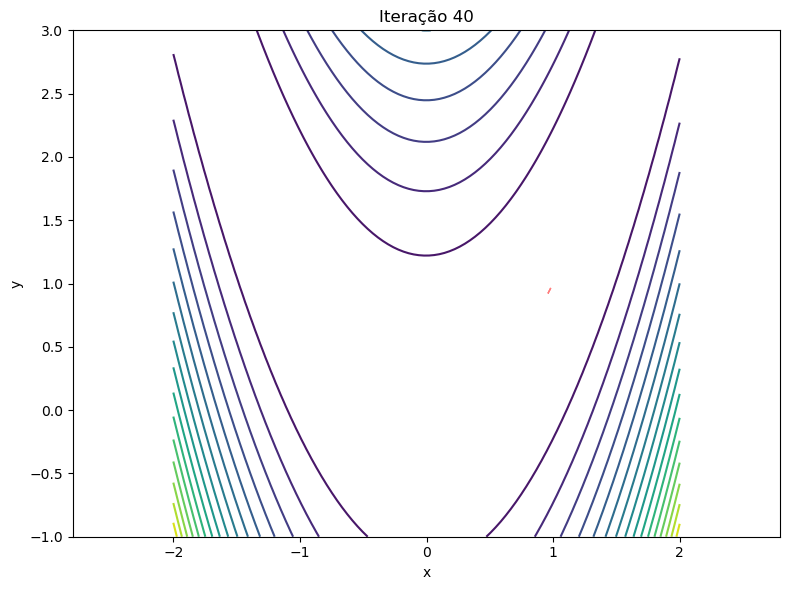

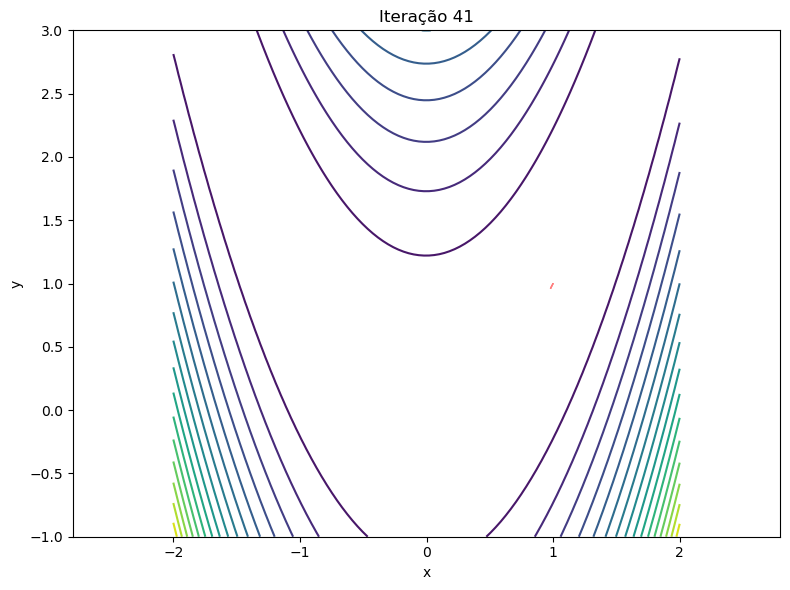

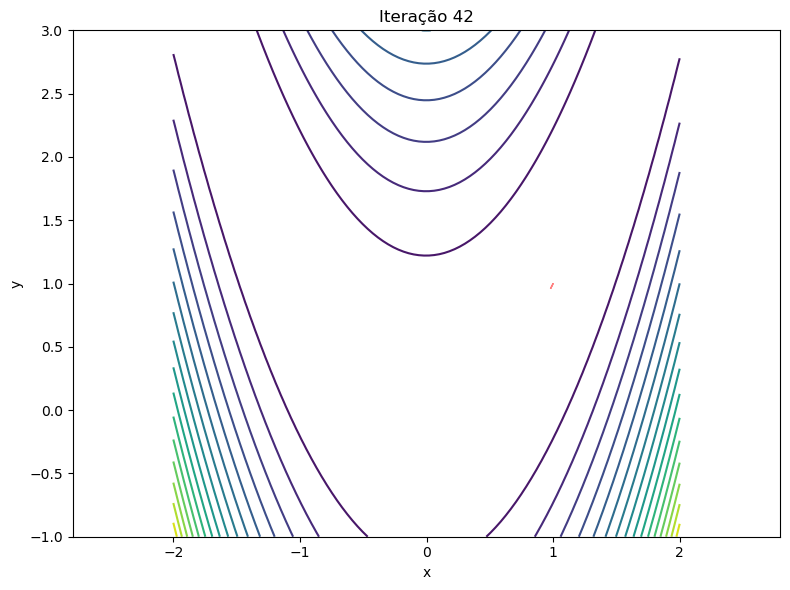

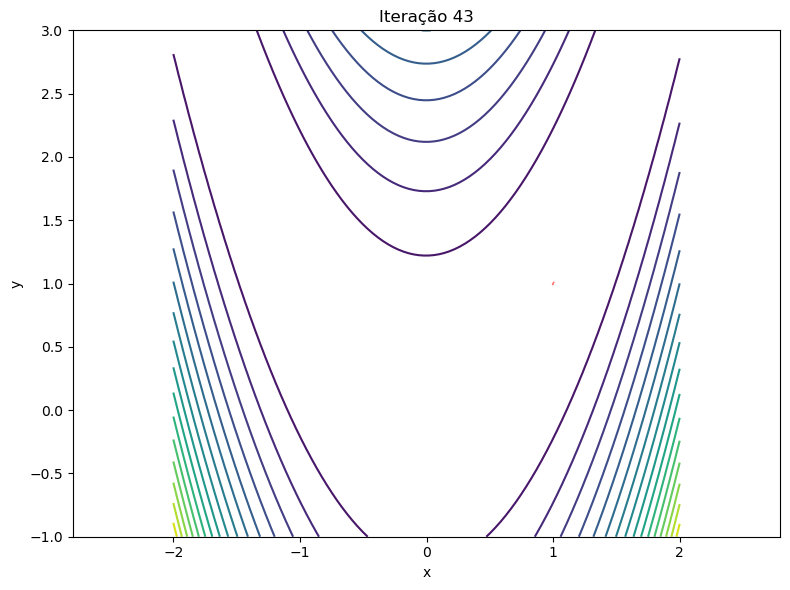

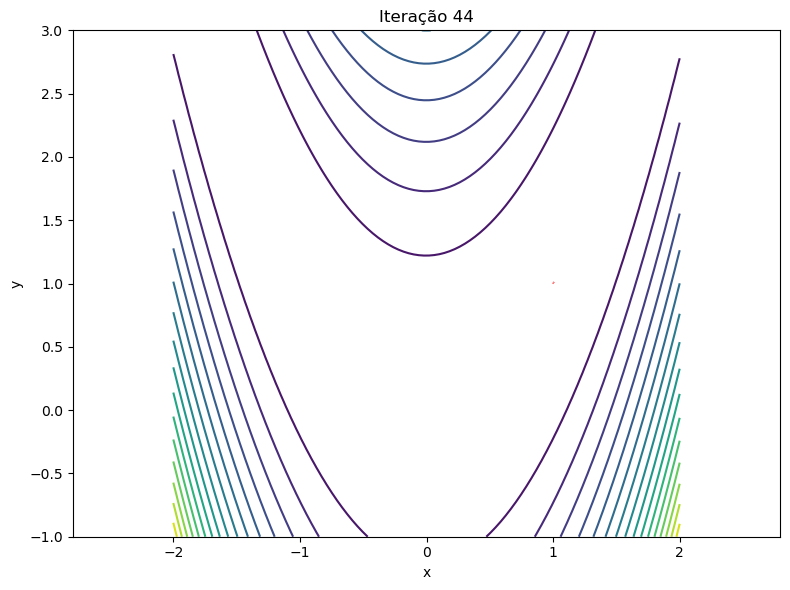

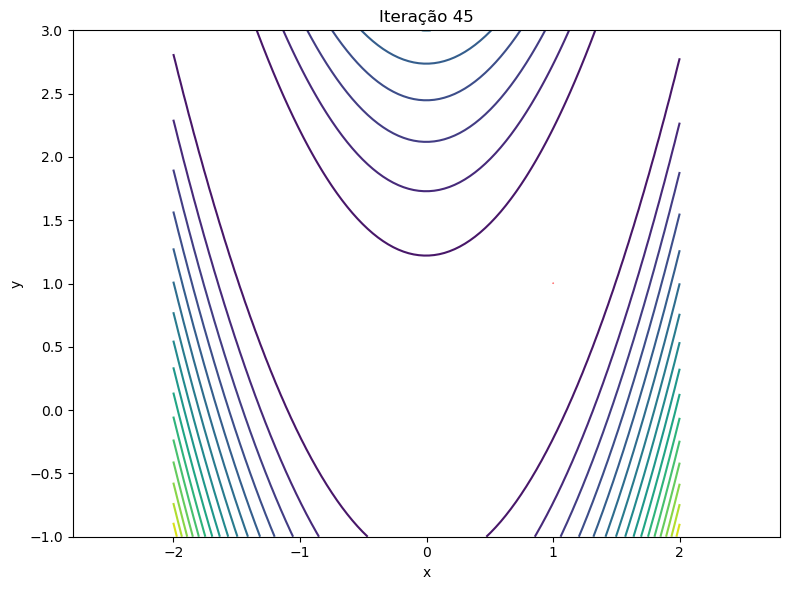

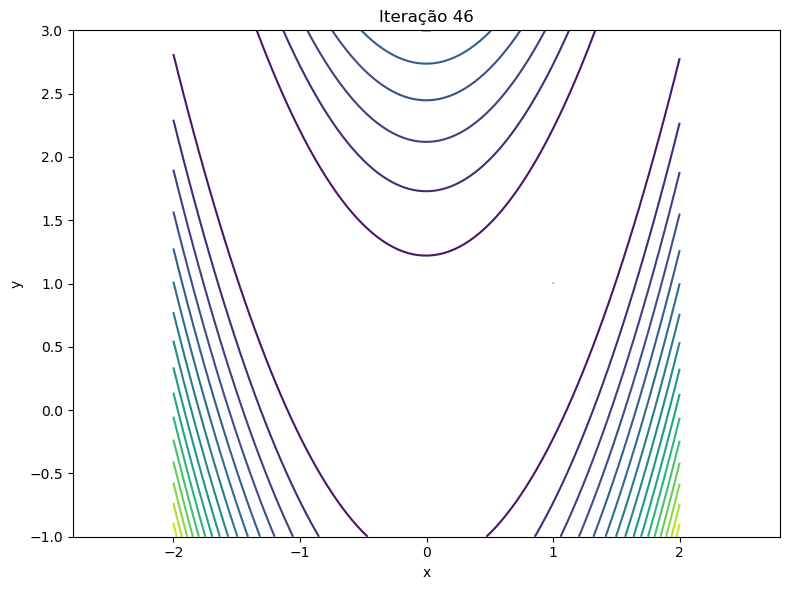

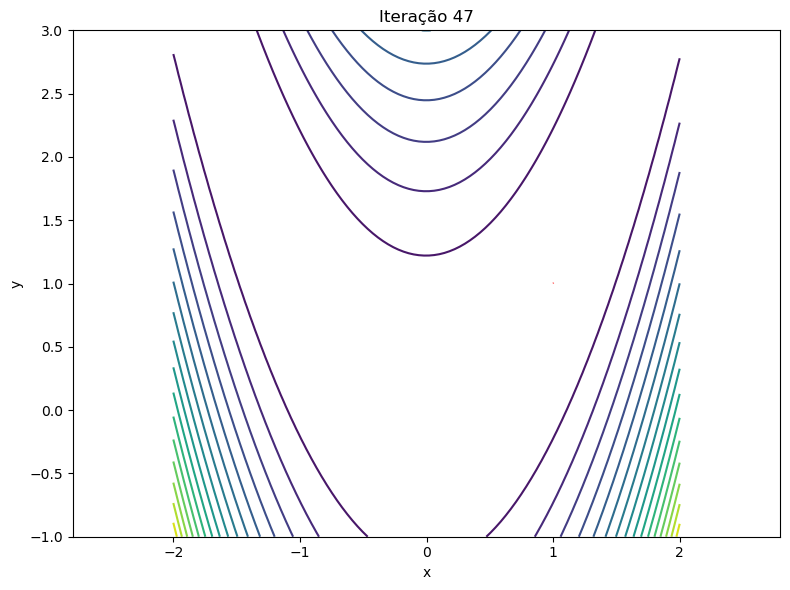

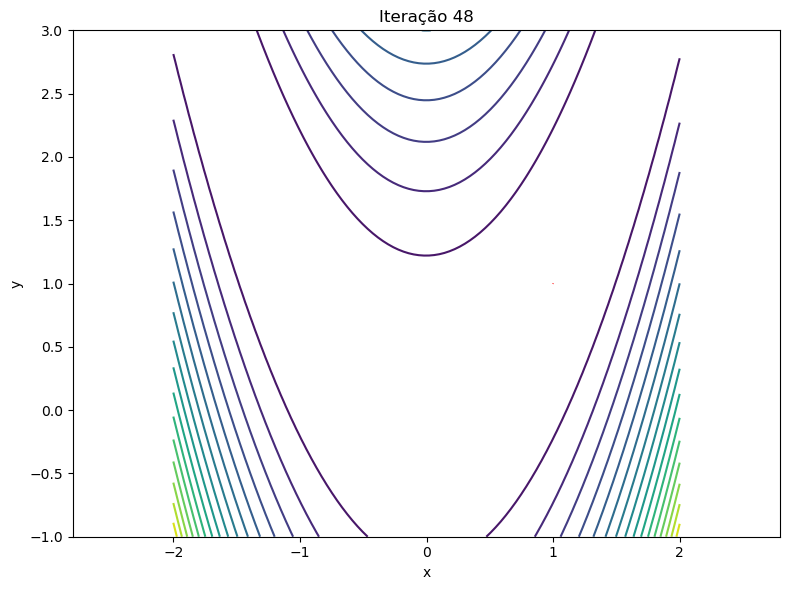

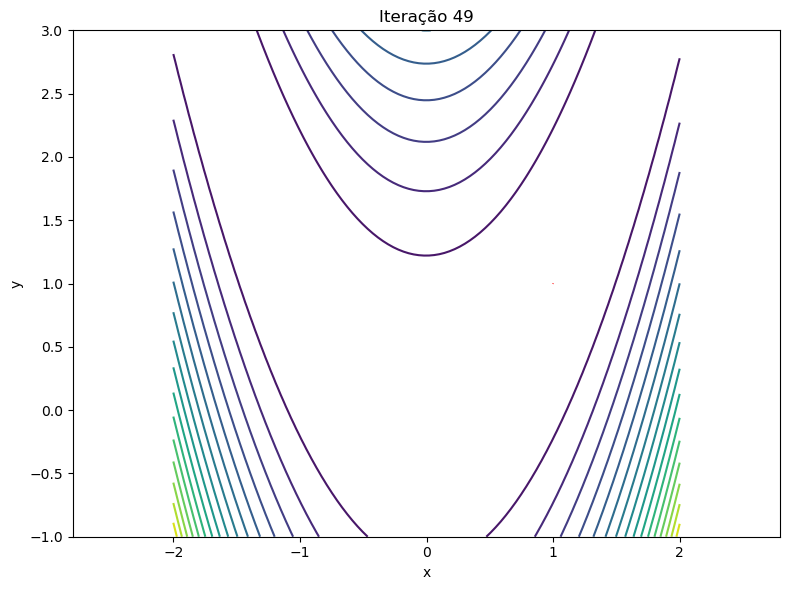

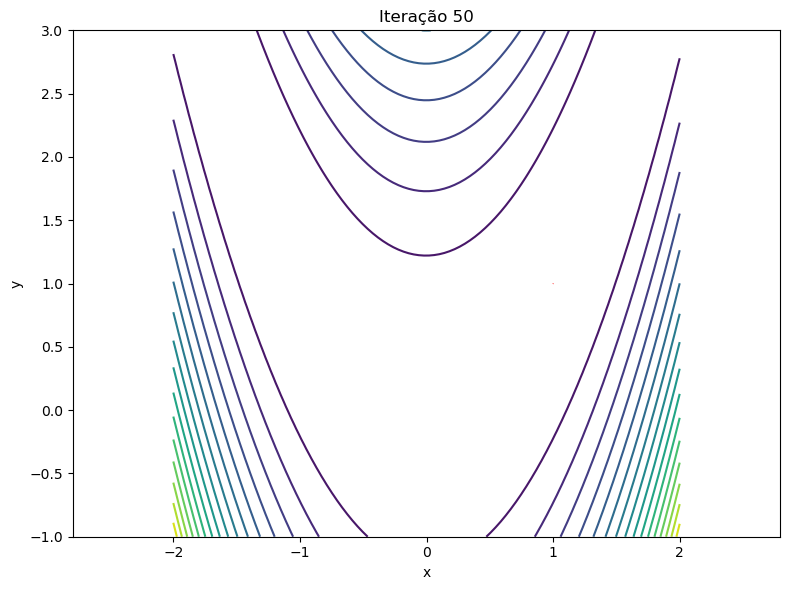

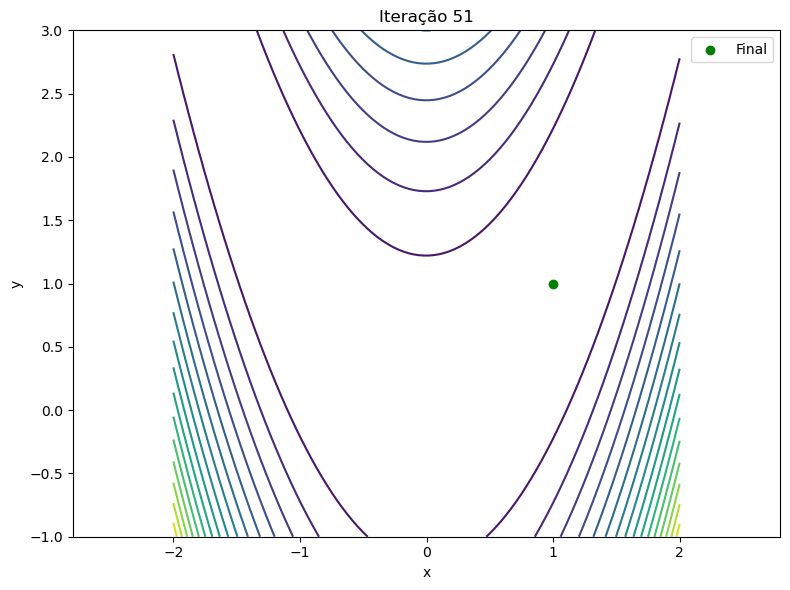

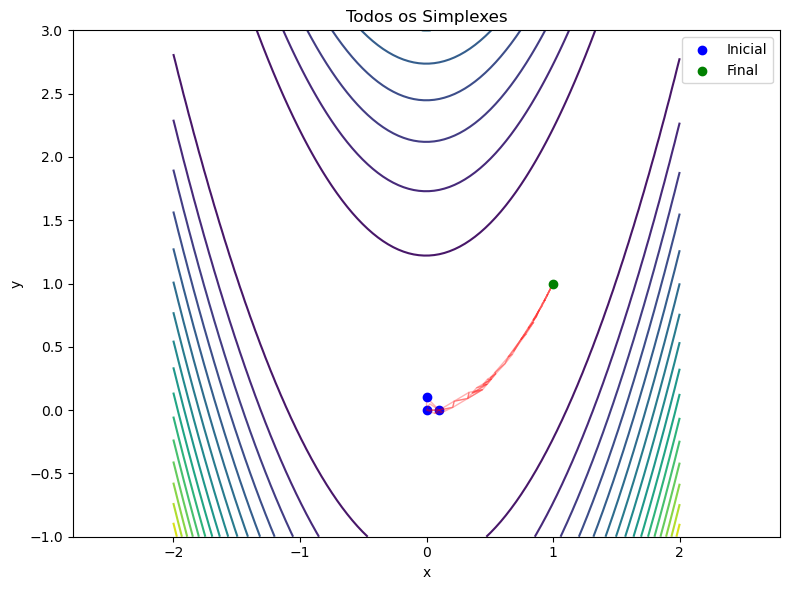

In [200]:
x0 = np.array([0.0, 0.0]) # Define ponto inicial (0, 0)
resultado, historico = nelder_mead(x0) #executa o Nelder-Mead
print(f"Resultado manual: {resultado}")

#Comparação com o método de Nelder-Mead do SciPy(apenas para comparação, não faz parte do algoritmo)
resultado_scipy = minimize(funcao_objetivo, x0, method='Nelder-Mead')
print(f"Resultado SciPy: {resultado_scipy.x}")

plt_evolucao(historico)